In [1]:
import pandas as pd

In [2]:
DATASET = '../../../datasets/libra/realdata/libra_380K.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,id_source,id_destination,cum_amount,nr_transactions,nr_alerts,nr_reports
0,0,349867,1400.00,1,0,0
1,0,351343,4000.00,1,0,0
2,0,350363,30560.00,4,0,0
3,0,349658,5200.00,2,0,0
4,1,351895,646.00,1,0,0
...,...,...,...,...,...,...
597160,385079,193633,458.00,1,0,0
597161,385081,356492,9.88,2,0,0
597162,385086,240249,12882.63,1,0,0
597163,385091,233659,230000.00,5,0,0


In [3]:
df['nr_alerts'].unique()

array([0, 1, 2, 3, 5, 6, 4])

In [4]:
# Dictionary to track the last step of each user
user_steps = {}

# Initialize the step column
df["step"] = 0
fraud = 0

# Iterate through transactions
for idx, row in df.iterrows():
    sender = row["id_source"]
    receiver = row["id_destination"]
    is_fraud = row["nr_reports"]
    n_alerts = row["nr_alerts"]
    n_transaction = row["nr_transactions"]
    
    # Get the last step for sender & receiver (default to -1 if not seen before)
    sender_step = user_steps.get(sender, -1)
    receiver_step = user_steps.get(receiver, -1)
    
    # Assign step: max(sender_step, receiver_step) + 1
    step = max(sender_step, receiver_step) + 1
    df.at[idx, "step"] = step

    # Update user steps
    user_steps[sender] = step
    user_steps[receiver] = step  # Both users are now at this step

    if is_fraud or n_alerts > 0:
        fraud += 1

In [5]:
print(f"Total fraudolent transactions: {fraud} out of {len(df)} transactions")
fraud_perc = fraud / len(df)
print(f"Anomaly percentage: {round(fraud_perc * 100, 2)}")

Total fraudolent transactions: 444 out of 597165 transactions
Anomaly percentage: 0.07


In [6]:
df

,id_source,id_destination,cum_amount,nr_transactions,nr_alerts,nr_reports,step
0,0,349867,1400.00,1,0,0,0
1,0,351343,4000.00,1,0,0,1
2,0,350363,30560.00,4,0,0,2
3,0,349658,5200.00,2,0,0,3
4,1,351895,646.00,1,0,0,0
...,...,...,...,...,...,...,...
597160,385079,193633,458.00,1,0,0,120762
597161,385081,356492,9.88,2,0,0,54700
597162,385086,240249,12882.63,1,0,0,1
597163,385091,233659,230000.00,5,0,0,3068


In [7]:
balances = {}

for _, row in df.iterrows():
    source = int(row["id_source"])
    destination = int(row["id_destination"])
    step = int(row["step"])
    amount = round(float(row["cum_amount"]), 3)  

    # Initialize balances if user appears for the first time
    if source not in balances:
        balances[source] = {step: 0}  # First transaction, balance starts at 0
    if destination not in balances:
        balances[destination] = {step: 0}

    # Get the previous balance (default to 0 if first transaction)
    prev_balance_source = max(balances[source].values(), default=0)
    prev_balance_destination = max(balances[destination].values(), default=0)

    # Update balances for this step
    balances[source][step] = round(prev_balance_source - amount, 3)  # Source loses money
    balances[destination][step] = round(prev_balance_destination + amount, 3)  # Destination gains money

In [8]:
balances

{0: {0: -1400.0, 1: -5400.0, 2: -31960.0, 3: -6600.0},
 349867: {0: 1400.0,
  1: 17810.0,
  2: 20610.0,
  3: 27410.0,
  4: 33199.61,
  16097: 43799.61,
  16098: 46579.61,
  16099: 60899.61,
  20823: 61559.61,
  42250: 74689.61,
  42251: 68986.61,
  42278: 71507.76,
  42279: 74636.61,
  42280: 28011.77,
  42281: 70992.61,
  42560: 74666.43,
  42561: 55318.35},
 351343: {1: 4000.0,
  2: 7870.0,
  15145: 15750.0,
  48337: 14655.0,
  48338: 8250.0,
  48339: 13750.0,
  48340: 15563.88,
  48347: -7958.0,
  48348: 14936.17,
  48528: 14769.77,
  48529: 13599.36,
  48530: 14135.17,
  48531: 14332.3,
  48532: 15595.39,
  48533: 13823.06},
 350363: {2: 30560.0,
  3: 49450.0,
  4: 50950.0,
  5: 62300.0,
  6: 62900.0,
  7: 139605.0,
  28: 140045.0,
  29: 140845.0,
  30: 142795.0,
  14401: 145680.0,
  14402: 152835.25,
  14403: 162185.25,
  20836: 165185.25,
  45627: 160938.25,
  45628: 79914.32,
  45629: 164685.45,
  45721: 164470.31,
  45722: 160645.25,
  45723: 160828.11,
  45724: 154982.94,
  45

In [ ]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(int(balance_df.index.min()), int(balance_df.index.max()) + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

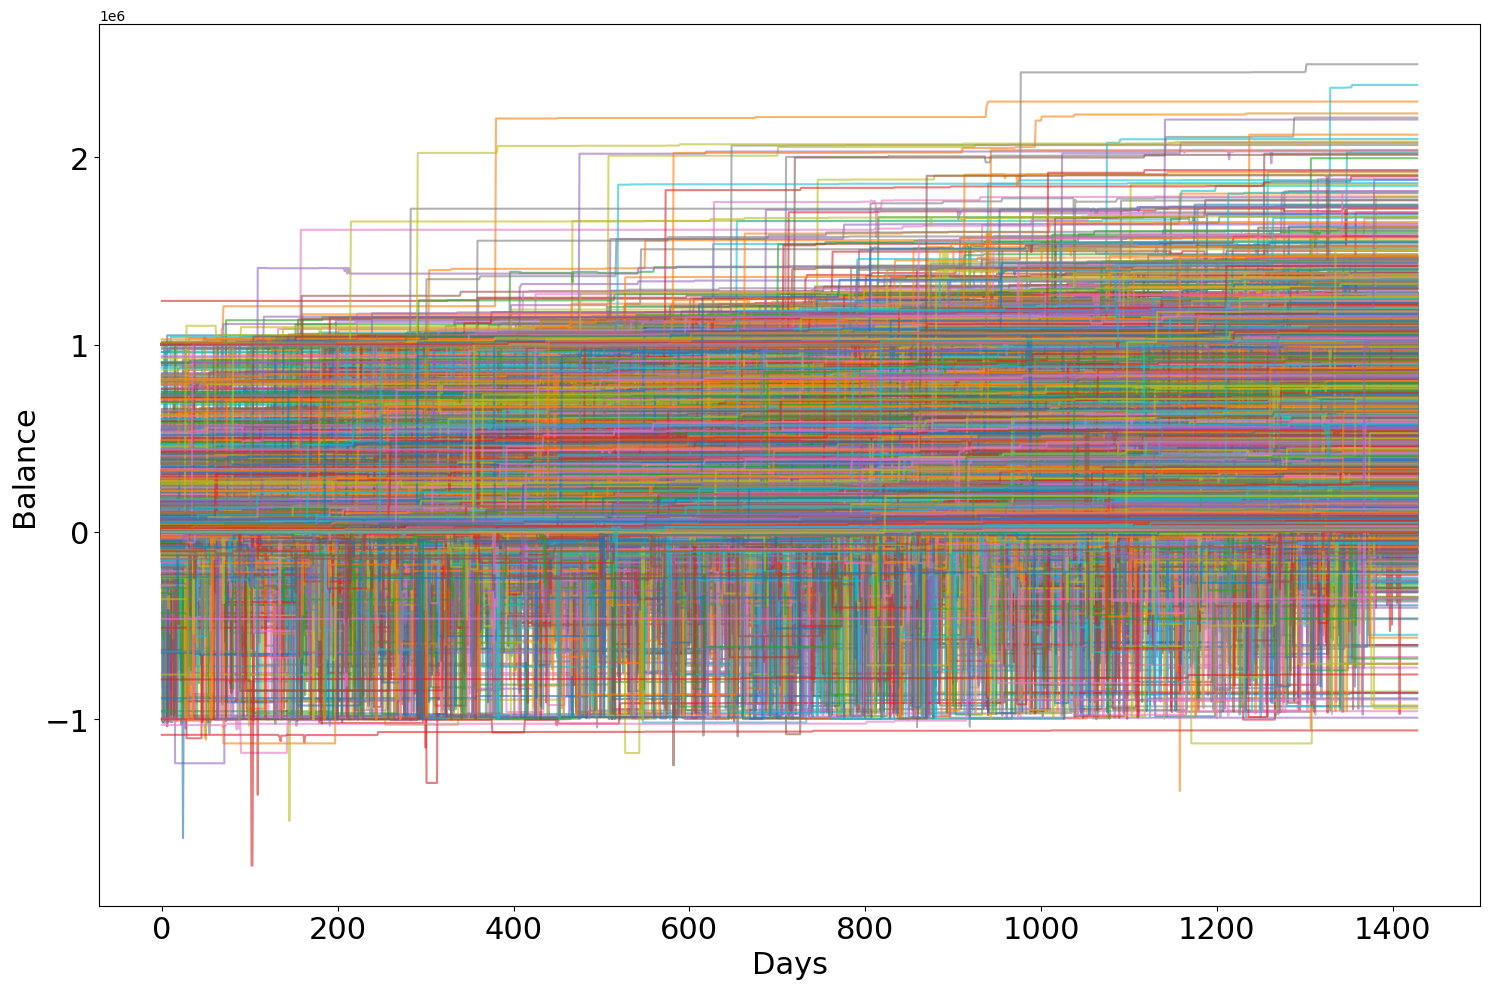

In [41]:
import matplotlib.pyplot as plt

# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    plt.plot(balance_df.index, balance_df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()